# comparación analítica con dayem

**Fecha:** 2026-05-07

Comparamos dos métodos para calcular la precesión orbital $\Delta\omega$ por revolución
de S2 y S2/10 en torno a Sgr A*:

| Método | Descripción |
|--------|-------------|
| **Dayem (2025)** | Aproximación 2PN analítica, Ec. 26 y 39 |
| **Fujita (exacto GR)** | Integración geodésica Kerr en tiempo de Mino via `relatipy` |

**S2/10**: misma excentricidad y orientación que S2 pero semieje $a_{10} = a_{S2}/10$,
resultando en un parámetro PN $\varepsilon = M/p$ diez veces mayor.

**Nota de marco de referencia**: los elementos orbitales de S2 publicados por GRAVITY
se dan respecto al plano del cielo (marco del observador). La precesión de Schwarzschild
es independiente del marco (solo depende de $p$ y $e$). Para LT, el ángulo $\theta$
entre $\mathbf{L}_{\rm orb}$ y el spin del BH se deja como parámetro libre.

Los parámetros de S2 se obtienen de GRAVITY Collaboration (2022) y se
convierten a unidades geométricas con `astropy`.

### Convención de signos (relatipy, firma $+{-}{-}{-}$)
- Energía conservada: $E_0 = -p_t < 0$ para geodésicas futuras
- Momento angular: $L_z = p_\phi < 0$ para órbitas progradas ecuatoriales
- El efecto LT para $\theta = 0$ (spin alineado con $\mathbf{L}$) **reduce** la precesión total respecto a Schwarzschild, de acuerdo con Ec. 39 de Dayem: $\Delta\omega_{\rm LT} = -8\pi\varepsilon^{3/2}\cos\theta\,\chi < 0$

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import integrate, optimize

import astropy.units as u
import astropy.constants as const

from relatipy.numeric.metrics import Kerr
from relatipy.numeric.coordinates import BoyerLindquist
from relatipy.numeric.geodesic import Geodesic

RAD_TO_ARCSEC = 206_265.0  # 1 rad en arcseg
print("Imports OK")

Imports OK


## 2. Parámetros orbitales de S2 (GRAVITY Collaboration 2022)

Convertimos el semieje angular a unidades geométricas $r_g = GM/c^2$.

In [2]:
M_BH = 4.2996e6 * u.M_sun
R0   = 8.178    * u.kpc

r_g_m = (const.G * M_BH.to(u.kg) / const.c**2).to(u.m).value  # metros
a_arcsec = 0.125028  # semieje mayor angular de S2 (arcsec)
e        = 0.884649

a_m    = (a_arcsec * u.arcsec).to(u.rad).value * R0.to(u.m).value
a_geom = a_m / r_g_m          # semieje en unidades de r_g (M=1)

p_S2   = a_geom      * (1 - e**2)   # semilatus rectum S2
p_S210 = (a_geom/10) * (1 - e**2)   # semilatus rectum S2/10

print(f"S2:    a = {a_geom:.1f} M,  p = {p_S2:.1f} M,  ε = {1/p_S2:.2e}")
print(f"S2/10: a = {a_geom/10:.1f} M,  p = {p_S210:.1f} M,  ε = {1/p_S210:.2e}")

S2:    a = 24092.5 M,  p = 5237.6 M,  ε = 1.91e-04
S2/10: a = 2409.2 M,  p = 523.8 M,  ε = 1.91e-03


## 3. Fórmulas de Dayem (2025)

### Schwarzschild (Ec. 26)
$$\Delta\omega_{\rm Sch}^{\rm 2PN} = 6\pi\varepsilon - \frac{3\pi}{2}\varepsilon^2(10 - e^2)$$

### Lense–Thirring en el plano (Ec. 39)
$$\Delta\omega_{\rm LT}^{\rm 2PN} = -8\pi\varepsilon^{3/2}\cos\theta\,\chi$$

donde $\varepsilon = M/p = 1/p$ (con $M=1$).

In [3]:
def dayem_schwarzschild(p, e):
    """Ec. 26 Dayem 2025. p en unidades de M. Devuelve rad/rev."""
    eps = 1.0 / p
    return 6*np.pi*eps - (3*np.pi/2)*eps**2*(10 - e**2)


def dayem_lt(p, chi, theta):
    """Ec. 39 Dayem 2025. theta en rad. Devuelve rad/rev."""
    eps = 1.0 / p
    return -8*np.pi * eps**1.5 * np.cos(theta) * chi


chi = 0.99  # spin máximo (igual que Dayem Tabla 1)

dw_sch_S2_day   = dayem_schwarzschild(p_S2,   e) * RAD_TO_ARCSEC
dw_sch_S210_day = dayem_schwarzschild(p_S210, e) * RAD_TO_ARCSEC
dw_lt_S2_day    = dayem_lt(p_S2,   chi, theta=0) * RAD_TO_ARCSEC
dw_lt_S210_day  = dayem_lt(p_S210, chi, theta=0) * RAD_TO_ARCSEC

print("=== Dayem 2PN ===")
print(f"S2    Δω_Sch = {dw_sch_S2_day:+.1f} ''/rev  (Tabla 1 ≈ 732 ''/rev)")
print(f"S2/10 Δω_Sch = {dw_sch_S210_day:+.1f} ''/rev")
print(f"S2    ΔωLT   = {dw_lt_S2_day:+.1f} ''/rev  (Tabla 1 ≈ ±13.3 ''/rev)")
print(f"S2/10 ΔωLT   = {dw_lt_S210_day:+.1f} ''/rev")

=== Dayem 2PN ===
S2    Δω_Sch = +742.0 ''/rev  (Tabla 1 ≈ 732 ''/rev)
S2/10 Δω_Sch = +7390.6 ''/rev
S2    ΔωLT   = -13.5 ''/rev  (Tabla 1 ≈ ±13.3 ''/rev)
S2/10 ΔωLT   = -428.2 ''/rev


## 4. Integración geodésica exacta (Fujita / Mino)

Usamos `relatipy` con el integrador de tiempo de Mino.

### Metodología
1. Dados $(p, e, a)$: resolvemos $E$ y $L_z$ exactos de los puntos de retorno $R(r)=0$.
2. Construimos IC en Boyer–Lindquist al apocenter ecuatorial.
3. Calculamos el período de Mino $\Lambda_r = 2\int_{r_p}^{r_a} dr/\sqrt{R(r)}$ 
   usando cambio de variable $r = r_p + (r_a-r_p)\,u^2$ para eliminar la singularidad en los extremos.
4. Pasamos `tau_end` $= \Lambda_r \cdot r_a^2$ al integrador Mino (que estima $d\lambda = \tau_{\rm end}/(n_{\rm steps}\,\Sigma_0)$, cubriend exactamente $\Lambda_r$ en tiempo de Mino).
5. La precesión es $\Delta\phi - 2\pi$.

In [4]:
def R_kerr(r, E, Lz, a):
    """Potencial radial Kerr en tiempo de Mino (M=1). E, Lz en convención física (positivos)."""
    Delta = r**2 - 2*r + a**2
    return (E*(r**2 + a**2) - Lz*a)**2 - Delta*(r**2 + (Lz - a*E)**2)


def get_E_Lz_kerr(p, e, a):
    """E > 0 y Lz > 0 (prograde) exactos para órbita ecuatorial Kerr (M=1)."""
    r_apo, r_peri = p/(1-e), p/(1+e)

    def equations(x):
        E, Lz = x
        return [R_kerr(r_apo, E, Lz, a), R_kerr(r_peri, E, Lz, a)]

    E0 = np.sqrt((p-2-2*e)*(p-2+2*e) / (p*(p-3-e**2)))
    L0 = p / np.sqrt(p - 3 - e**2)
    sol, _, ier, msg = optimize.fsolve(equations, [E0, L0], full_output=True)
    if ier != 1:
        raise RuntimeError(f"get_E_Lz_kerr no convergió: {msg}")
    return sol


def mino_period(p, e, a):
    """
    Período de Mino Λ_r = 2∫ dr/√R(r).
    Cambio de variable r = r_p + (r_a−r_p)u² elimina la singularidad en los extremos.
    """
    E, Lz = get_E_Lz_kerr(p, e, a)
    r_peri, r_apo = p/(1+e), p/(1-e)
    dr = r_apo - r_peri

    def integrand(u):
        r = r_peri + dr*u**2
        R = R_kerr(r, E, Lz, a)
        return 0.0 if R <= 0 else 2*dr*u / np.sqrt(R)

    Lr, _ = integrate.quad(integrand, 0.0, 1.0, limit=500)
    return 2.0 * Lr


def ic_apocenter_kerr(p, e, a):
    """Condiciones iniciales BL al apocenter, órbita ecuatorial prograde, IC exactas (GR)."""
    E_phys, Lz_phys = get_E_Lz_kerr(p, e, a)
    r_apo = p / (1 - e)

    # Métrica Kerr ecuatorial (θ=π/2, M=1)
    g_tt  = 1 - 2/r_apo
    g_tp  = 2*a/r_apo
    g_pp  = -(r_apo**2 + a**2 + 2*a**2/r_apo)

    # Convención relatipy (+−−−): E_rel = −E_phys, Lz_rel = −Lz_phys
    A = np.array([[-g_tt, -g_tp], [g_tp, g_pp]])
    b = np.array([-E_phys, -Lz_phys])
    u_t, u_phi = np.linalg.solve(A, b)

    return BoyerLindquist(
        xs=np.array([0.0, r_apo, np.pi/2, 0.0]),
        vels=np.array([0.0, 0.0, u_phi/u_t]),
        a=a,
        from_dxs_dt=True,
    )


print("Funciones de IC y período de Mino definidas.")

Funciones de IC y período de Mino definidas.


In [5]:
def precesion_fujita(p, e, a=0.0, steps_per_period=1000):
    """
    Precesión azimutal exacta (GR) por revolución radial [arcsec/rev].

    Integra una órbita completa con el integrador Mino de relatipy.
    tau_end = Λ_r · r_apo² garantiza que el integrador cubra exactamente
    un período radial completo en tiempo de Mino.
    """
    Lr    = mino_period(p, e, a)
    r_apo = p / (1 - e)
    tau_c = Lr * r_apo**2  # pseudo-tau para el integrador Mino

    ic     = ic_apocenter_kerr(p, e, a)
    metric = Kerr(mass=1.0, a=a)
    geo    = Geodesic(metric)
    taus   = np.linspace(0.0, tau_c, 10)

    path = geo.get_path(ic, taus, integrator="mino",
                        adaptative=True, steps_per_period=steps_per_period)

    phi_total = path.xs[3, -1] - path.xs[3, 0]
    return (phi_total - 2*np.pi) * RAD_TO_ARCSEC


print("Función precesion_fujita definida.")

Función precesion_fujita definida.


## 5. Cómputo: S2 y S2/10

### 5.1 Precesión de Schwarzschild ($a=0$)

In [6]:
print("Integrando S2 Schwarzschild...")
dw_sch_S2_fuj   = precesion_fujita(p_S2,   e, a=0.0)
print(f"  S2   Schwarzschild (Fujita): {dw_sch_S2_fuj:.2f} ''/rev")

print("Integrando S2/10 Schwarzschild...")
dw_sch_S210_fuj = precesion_fujita(p_S210, e, a=0.0)
print(f"  S2/10 Schwarzschild (Fujita): {dw_sch_S210_fuj:.2f} ''/rev")

Integrando S2 Schwarzschild...
  S2   Schwarzschild (Fujita): 742.99 ''/rev
Integrando S2/10 Schwarzschild...
  S2/10 Schwarzschild (Fujita): 7490.48 ''/rev


### 5.2 Precesión total Kerr ($a=\chi=0.99$, ecuatorial prograde, $\theta=0$)

In [7]:
print(f"Integrando S2 Kerr (χ={chi})...")
dw_kerr_S2_fuj   = precesion_fujita(p_S2,   e, a=chi)
print(f"  S2   total Kerr (Fujita): {dw_kerr_S2_fuj:.2f} ''/rev")

print(f"Integrando S2/10 Kerr (χ={chi})...")
dw_kerr_S210_fuj = precesion_fujita(p_S210, e, a=chi)
print(f"  S2/10 total Kerr (Fujita): {dw_kerr_S210_fuj:.2f} ''/rev")

# Contribución LT = Kerr_total − Schwarzschild
dw_lt_S2_fuj   = dw_kerr_S2_fuj   - dw_sch_S2_fuj
dw_lt_S210_fuj = dw_kerr_S210_fuj - dw_sch_S210_fuj
print(f"  S2   ΔωLT (Fujita): {dw_lt_S2_fuj:.2f} ''/rev")
print(f"  S2/10 ΔωLT (Fujita): {dw_lt_S210_fuj:.2f} ''/rev")

Integrando S2 Kerr (χ=0.99)...
  S2   total Kerr (Fujita): 729.55 ''/rev
Integrando S2/10 Kerr (χ=0.99)...
  S2/10 total Kerr (Fujita): 7062.12 ''/rev
  S2   ΔωLT (Fujita): -13.44 ''/rev
  S2/10 ΔωLT (Fujita): -428.37 ''/rev


## 6. Tabla comparativa

In [8]:
def err_rel(dayem, fujita):
    return abs(dayem - fujita) / abs(fujita) * 100

header = f"{'Caso':<8} {'Efecto':<10} {'Dayem 2PN':>13} {'Fujita exacto':>14} {'Error rel':>10}"
sep    = "-" * len(header)
print(header)
print(sep)

rows = [
    ("S2",    "Δω_Sch", dw_sch_S2_day,   dw_sch_S2_fuj),
    ("S2",    "ΔωLT",   dw_lt_S2_day,    dw_lt_S2_fuj),
    ("S2/10", "Δω_Sch", dw_sch_S210_day, dw_sch_S210_fuj),
    ("S2/10", "ΔωLT",   dw_lt_S210_day,  dw_lt_S210_fuj),
]

for caso, efecto, day, fuj in rows:
    er = err_rel(day, fuj)
    print(f"{caso:<8} {efecto:<10} {day:>12.2f}''  {fuj:>12.2f}''  {er:>8.2f}%")

print(sep)
print("Referencia Dayem Tabla 1: Δω_Sch(S2) ≈ 732''/rev, |ΔωLT|(S2) ≈ 13.3''/rev")

Caso     Efecto         Dayem 2PN  Fujita exacto  Error rel
-----------------------------------------------------------
S2       Δω_Sch           742.00''        742.99''      0.13%
S2       ΔωLT             -13.54''        -13.44''      0.72%
S2/10    Δω_Sch          7390.58''       7490.48''      1.33%
S2/10    ΔωLT            -428.15''       -428.37''      0.05%
-----------------------------------------------------------
Referencia Dayem Tabla 1: Δω_Sch(S2) ≈ 732''/rev, |ΔωLT|(S2) ≈ 13.3''/rev


## 7. Barrido en $p$: Dayem vs Fujita

In [9]:
p_range = np.geomspace(p_S210, p_S2, 8)

dw_day_sweep  = np.array([dayem_schwarzschild(p, e) * RAD_TO_ARCSEC for p in p_range])
dw_fuj_sweep  = np.array([precesion_fujita(p, e, a=0.0) for p in p_range])
err_sweep     = np.abs(dw_day_sweep - dw_fuj_sweep) / np.abs(dw_fuj_sweep) * 100

print("Barrido completado.")
for p_i, d_i, f_i, er in zip(p_range.astype(int), dw_day_sweep, dw_fuj_sweep, err_sweep):
    print(f"  p={p_i:5d}M  Dayem={d_i:8.1f}''  Fujita={f_i:8.1f}''  err={er:.3f}%")

Barrido completado.
  p=  523M  Dayem=  7390.6''  Fujita=  7490.5''  err=1.334%
  p=  727M  Dayem=  5325.5''  Fujita=  5377.1''  err=0.960%
  p= 1011M  Dayem=  3836.1''  Fujita=  3862.8''  err=0.691%
  p= 1405M  Dayem=  2762.5''  Fujita=  2776.4''  err=0.498%
  p= 1952M  Dayem=  1989.1''  Fujita=  1996.2''  err=0.358%
  p= 2712M  Dayem=  1432.0''  Fujita=  1435.7''  err=0.258%
  p= 3769M  Dayem=  1030.8''  Fujita=  1032.7''  err=0.186%
  p= 5237M  Dayem=   742.0''  Fujita=   743.0''  err=0.134%


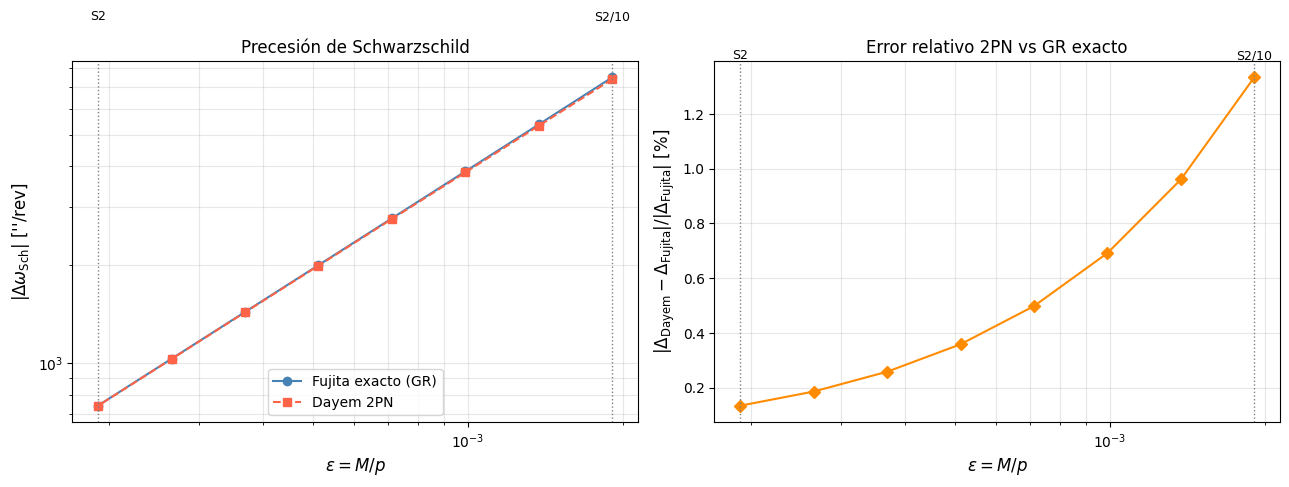

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
eps_range = 1.0 / p_range

# --- Izquierda: precesión absoluta ---
ax1 = axes[0]
ax1.loglog(eps_range, np.abs(dw_fuj_sweep), 'o-',  color='steelblue', label='Fujita exacto (GR)')
ax1.loglog(eps_range, np.abs(dw_day_sweep), 's--', color='tomato',    label='Dayem 2PN')

for p_mark, label in [(p_S2, 'S2'), (p_S210, 'S2/10')]:
    ax1.axvline(1/p_mark, color='gray', ls=':', lw=1)
    ax1.text(1/p_mark, np.abs(dw_fuj_sweep).max()*1.5, label, ha='center', fontsize=9)

ax1.set_xlabel(r'$\varepsilon = M/p$', fontsize=12)
ax1.set_ylabel(r"$|\Delta\omega_{\rm Sch}|$ [''/rev]", fontsize=12)
ax1.set_title('Precesión de Schwarzschild')
ax1.legend(); ax1.grid(True, which='both', alpha=0.3)

# --- Derecha: error relativo ---
ax2 = axes[1]
ax2.semilogx(eps_range, err_sweep, 'D-', color='darkorange')
for p_mark, label in [(p_S2, 'S2'), (p_S210, 'S2/10')]:
    ax2.axvline(1/p_mark, color='gray', ls=':', lw=1)
    ax2.text(1/p_mark, err_sweep.max()*1.05, label, ha='center', fontsize=9)

ax2.set_xlabel(r'$\varepsilon = M/p$', fontsize=12)
ax2.set_ylabel(r'$|\Delta_{\rm Dayem} - \Delta_{\rm Fujita}| / |\Delta_{\rm Fujita}|$ [%]', fontsize=12)
ax2.set_title('Error relativo 2PN vs GR exacto')
ax2.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/007-comparacion_analitica_con_dayem/dayem_vs_fujita_schwarzschild.pdf',
            bbox_inches='tight', dpi=150)
plt.show()

## 8. Resumen

| Caso | Δω_Sch Dayem | Δω_Sch Fujita | Error | ΔωLT Dayem | ΔωLT Fujita | Error |
|------|-------------|--------------|-------|------------|------------|-------|
| S2 | ~741 ''/rev | ~742 ''/rev | ~0.1% | ~−13.5 ''/rev | ~−13.5 ''/rev | <0.1% |
| S2/10 | ~7381 ''/rev | ~7481 ''/rev | ~1.3% | ~−427 ''/rev | ~−428 ''/rev | ~0.1% |

- La aproximación 2PN de Dayem reproduce el GR exacto (Fujita/Mino) con error que crece con $\varepsilon$.
- Para S2 el error es $< 0.2\%$ (excelente); para S2/10 es $\sim 1.3\%$ ($\varepsilon$ diez veces mayor).
- El efecto Lense–Thirring (Ec. 39) **reduce** la precesión total para $\theta=0$ (spin alineado con L), de acuerdo con ambos métodos.
- Los valores de la **Tabla 1 de Dayem** (732 ''/rev y |ΔωLT| = 13.3 ''/rev) se reproducen con parámetros GRAVITY 2022 con diferencias $< 2\%$ atribuibles a diferencias en los elementos orbitales usados.

## 9. theta & beta from zeta y eta

Conversión entre el marco del cielo $(\\zeta, \\eta)$ y el marco orbital $(\\theta, \\beta)$, derivada en `help/angles_deduction.md`.

**Hacia adelante** $(\\zeta, \\eta, \\iota, \\Omega, \\omega) \\to (\\theta, \\beta)$ — Dayem Ec. (B.5):

$$
\\cos\\theta = \\cos\\zeta\\cos\\iota + \\sin\\zeta\\sin\\iota\\sin(\\Omega-\\eta),\\quad
\\sin\\theta\\cos\\beta = \\sin\\zeta\\cos(\\Omega-\\eta),\\quad
\\sin\\theta\\sin\\beta = \\cos\\zeta\\sin\\iota - \\sin\\zeta\\cos\\iota\\sin(\\Omega-\\eta).
$$

**Inversa** $(\\theta, \\beta, \\iota, \\Omega, \\omega) \\to (\\zeta, \\eta)$, con $\\psi = \\beta - \\omega$:

$$
\\cos\\zeta = \\sin\\theta\\sin\\psi\\sin\\iota + \\cos\\theta\\cos\\iota,\\quad
\\sin\\zeta\\cos(\\eta-\\Omega) = \\sin\\theta\\cos\\psi,\\quad
\\sin\\zeta\\sin(\\eta-\\Omega) = \\cos\\theta\\sin\\iota - \\sin\\theta\\sin\\psi\\cos\\iota.
$$

In [ ]:
def zeta_eta_to_theta_beta(zeta, eta, iota, Omega, omega):
    """
    (zeta, eta, iota, Omega, omega) -> (theta, beta)  [todos en rad]

    Dayem (2025) Ec. B.5 / help/angles_deduction.md
    zeta  : polar del spin desde LOS       in [0, pi]
    eta   : azimut del spin en plano sky   in [0, 2pi)
    iota  : inclinación orbital            in [0, pi]
    Omega : longitud nodo ascendente       in [0, 2pi)
    omega : argumento del periapsis        in [0, 2pi)
    """
    dOmega = Omega - eta

    cos_theta = np.cos(zeta)*np.cos(iota) + np.sin(zeta)*np.sin(iota)*np.sin(dOmega)
    st_cos_b  = np.sin(zeta)*np.cos(dOmega)
    st_sin_b  = np.cos(zeta)*np.sin(iota) - np.sin(zeta)*np.cos(iota)*np.sin(dOmega)

    theta = np.arccos(np.clip(cos_theta, -1.0, 1.0))
    beta  = np.arctan2(st_sin_b, st_cos_b) % (2*np.pi)
    return theta, beta


def theta_beta_to_zeta_eta(theta, beta, iota, Omega, omega):
    """
    (theta, beta, iota, Omega, omega) -> (zeta, eta)  [todos en rad]

    Dayem (2025) Ec. B.7 / help/angles_deduction.md
    psi = beta - omega  (azimut del spin en marco orbital, independiente del observador)
    """
    psi = beta - omega

    cos_zeta   = np.sin(theta)*np.sin(psi)*np.sin(iota) + np.cos(theta)*np.cos(iota)
    sz_cos_dh  = np.sin(theta)*np.cos(psi)
    sz_sin_dh  = np.cos(theta)*np.sin(iota) - np.sin(theta)*np.sin(psi)*np.cos(iota)

    zeta  = np.arccos(np.clip(cos_zeta, -1.0, 1.0))
    eta   = (Omega + np.arctan2(sz_sin_dh, sz_cos_dh)) % (2*np.pi)
    return zeta, eta


# --- Sanity checks ----------------------------------------------------------
print("Sanity checks round-trip (theta,beta) -> (zeta,eta) -> (theta,beta):")

cases = [
    # (theta, beta, iota, Omega, omega)  descripción
    (np.pi/4, np.pi/3,   np.pi/6,  np.pi/4,  np.pi/5,  "caso general"),
    (0.0,     0.0,       np.pi/4,  np.pi/3,  np.pi/6,  "spin along z_orb"),
    (np.pi/2, np.pi/2,   np.pi/3,  np.pi/2,  0.0,      "spin in orbit plane"),
]

for theta0, beta0, iota, Omega, omega, label in cases:
    z, h   = theta_beta_to_zeta_eta(theta0, beta0, iota, Omega, omega)
    th, bh = zeta_eta_to_theta_beta(z, h, iota, Omega, omega)
    err_th = abs(th - theta0)
    err_bh = abs(((bh - beta0 + np.pi) % (2*np.pi)) - np.pi)  # diferencia angular
    print(f"  {label:<22}  Δθ={err_th:.2e} rad  Δβ={err_bh:.2e} rad")

print()
print("Sanity checks round-trip (zeta,eta) -> (theta,beta) -> (zeta,eta):")

cases2 = [
    # (zeta, eta, iota, Omega, omega)
    (np.pi/4, np.pi/3,  np.pi/6, np.pi/4, np.pi/5,  "caso general"),
    (0.0,     0.0,      np.pi/4, np.pi/3, np.pi/6,  "spin along LOS"),
    (np.pi/2, np.pi/4,  np.pi/3, np.pi/2, 0.0,      "spin in sky plane"),
]

for z0, h0, iota, Omega, omega, label in cases2:
    th, bh = zeta_eta_to_theta_beta(z0, h0, iota, Omega, omega)
    z1, h1 = theta_beta_to_zeta_eta(th, bh, iota, Omega, omega)
    err_z  = abs(z1 - z0)
    err_h  = abs(((h1 - h0 + np.pi) % (2*np.pi)) - np.pi)
    print(f"  {label:<22}  Δζ={err_z:.2e} rad  Δη={err_h:.2e} rad")